# Assignment 2 - Problem 3.1: The Filter Gallery



**Tasks**:
1. Train a Simple CNN (2 layers) on MNIST.
2. Train a Simple CNN (2 layers) on Tiny-ImageNet-10.
3. Train a FCNN (3 layers) on MNIST (for comparison using user-specified architecture).
4. Visualize and compare the first layer filters/weights.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torchvision.datasets import ImageFolder, MNIST
from torch.utils.data import DataLoader

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"Using device: {device}")

PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)

Using device: cpu


## 1. Data Loading

In [2]:
def get_dataloaders(batch_size=64):
    # MNIST
    transform_mnist = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    train_mnist = MNIST(root='./data', train=True, download=True, transform=transform_mnist)
    loader_mnist = DataLoader(train_mnist, batch_size=batch_size, shuffle=True)

    # Tiny ImageNet
    # Path relative to Assignment2 folder
    tiny_path = '../datasets/tiny-imagenet/train'
    
    if os.path.exists(tiny_path):
        transform_tiny = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        train_tiny = ImageFolder(root=tiny_path, transform=transform_tiny)
        loader_tiny = DataLoader(train_tiny, batch_size=batch_size, shuffle=True)
        print(f"Tiny ImageNet loaded from {tiny_path}. Classes: {len(train_tiny.classes)}")
    else:
        print(f"Warning: Tiny ImageNet path {tiny_path} not found.")
        loader_tiny = None

    return loader_mnist, loader_tiny

loader_mnist, loader_tiny = get_dataloaders()

100.0%
100.0%
100.0%
100.0%

Tiny ImageNet loaded from ../datasets/tiny-imagenet/train. Classes: 10


## 2. Model Definitions

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, input_dim=28):
        super(SimpleCNN, self).__init__()
        # Layer 1: Conv -> ReLU -> MaxPool
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # Layer 2: Conv -> ReLU -> MaxPool
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.flatten = nn.Flatten()
        
        # Calculate linear layer input size
        # Pool factor total is 4. 
        # 28 -> 7. 64 -> 16.
        final_dim = input_dim // 4
        self.feature_size = 32 * final_dim * final_dim
        self.fc = nn.Linear(self.feature_size, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

# User provided FCNN architecture
class FCNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()
        # define the structure of each layer
        self.input = nn.Linear(28*28, 128) 
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    # the forward pass
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x
    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions

## 3. Training Loop

In [4]:
def train_model(model, loader, epochs=5, name="Model"):
    if loader is None:
        print(f"Skipping training for {name}: No data")
        return model
        
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    
    print(f"\nTraining {name}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for i, (images, labels) in enumerate(loader):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/len(loader):.4f} | Acc: {100*correct/total:.2f}%")
    
    return model

## 4. Train Models

In [5]:
# 1. Simple CNN on MNIST
cnn_mnist = SimpleCNN(in_channels=1, num_classes=10, input_dim=28)
cnn_mnist = train_model(cnn_mnist, loader_mnist, epochs=3, name="CNN_MNIST")

# 2. Simple CNN on Tiny ImageNet
if loader_tiny:
    cnn_tiny = SimpleCNN(in_channels=3, num_classes=10, input_dim=64)
    cnn_tiny = train_model(cnn_tiny, loader_tiny, epochs=10, name="CNN_TinyImageNet") # More epochs for harder dataset

# 3. FCNN on MNIST (Comparison)
fcnn_mnist = FCNN()
fcnn_mnist = train_model(fcnn_mnist, loader_mnist, epochs=5, name="FCNN_MNIST")


Training CNN_MNIST...
Epoch 1/3 | Loss: 0.1910 | Acc: 94.26%
Epoch 2/3 | Loss: 0.0585 | Acc: 98.21%
Epoch 3/3 | Loss: 0.0448 | Acc: 98.58%

Training CNN_TinyImageNet...
Epoch 1/10 | Loss: 2.0209 | Acc: 26.58%
Epoch 2/10 | Loss: 1.6448 | Acc: 43.74%
Epoch 3/10 | Loss: 1.4653 | Acc: 51.14%
Epoch 4/10 | Loss: 1.2990 | Acc: 56.14%
Epoch 5/10 | Loss: 1.1805 | Acc: 61.78%
Epoch 6/10 | Loss: 0.9982 | Acc: 66.76%
Epoch 7/10 | Loss: 0.9065 | Acc: 70.76%
Epoch 8/10 | Loss: 0.7864 | Acc: 74.52%
Epoch 9/10 | Loss: 0.6613 | Acc: 79.14%
Epoch 10/10 | Loss: 0.5392 | Acc: 83.02%

Training FCNN_MNIST...
Epoch 1/5 | Loss: 0.2682 | Acc: 91.78%
Epoch 2/5 | Loss: 0.1096 | Acc: 96.57%
Epoch 3/5 | Loss: 0.0774 | Acc: 97.61%
Epoch 4/5 | Loss: 0.0617 | Acc: 98.03%
Epoch 5/5 | Loss: 0.0501 | Acc: 98.36%


## 5. Visualization

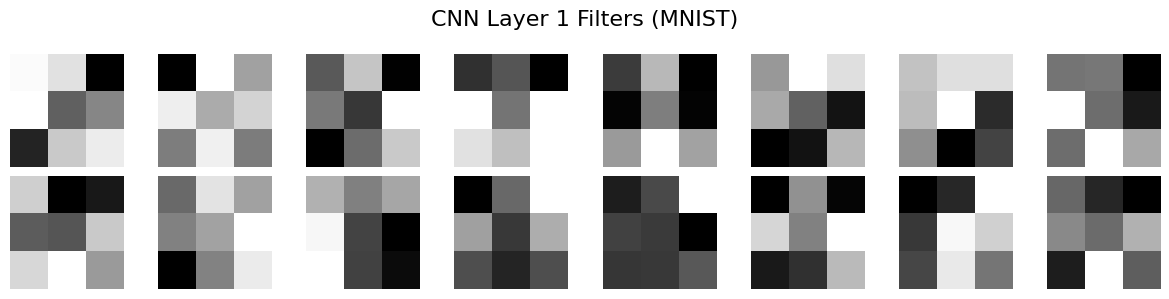

Saved cnn_mnist_filters.png


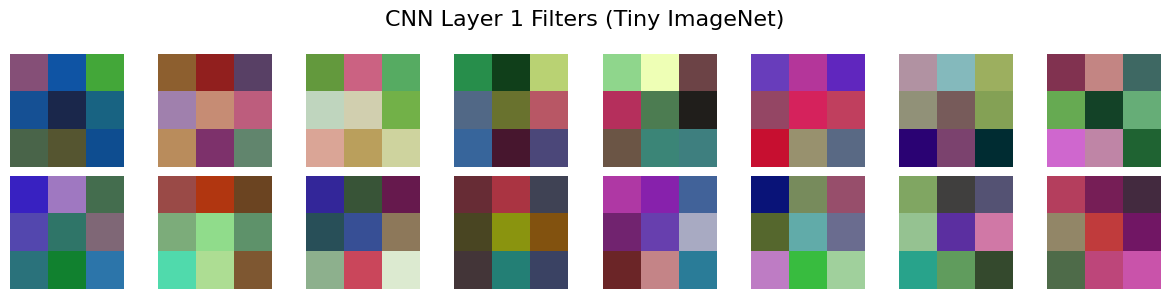

Saved cnn_tiny_filters.png


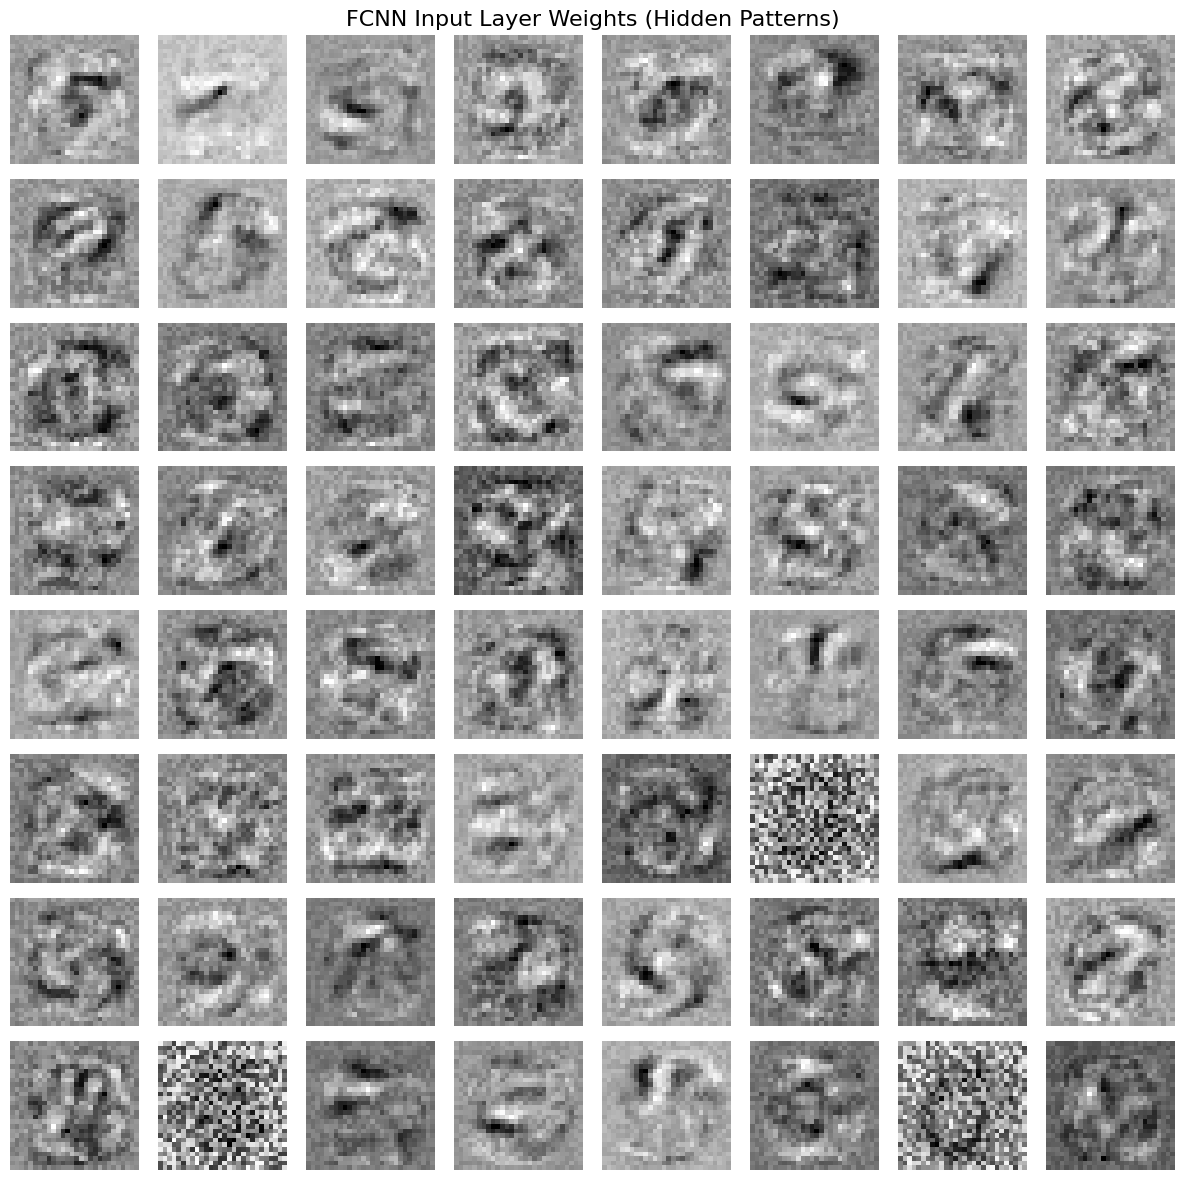

Saved fcnn_mnist_weights.png


In [6]:
def visualize_filters(weights, title, channels=1, save_name="plot.png"):
    # weights: [out_channels, in_channels, k, k]
    n = weights.shape[0]
    
    # Normalize to 0-1
    w_min = weights.min()
    w_max = weights.max()
    weights = (weights - w_min) / (w_max - w_min)
    
    cols = 8
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    fig.suptitle(title, fontsize=16)
    
    for i in range(rows * cols):
        ax = axes.flat[i] if rows * cols > 1 else axes
        if i < n:
            img = weights[i].detach().cpu().numpy()
            if channels == 1:
                ax.imshow(img[0], cmap='gray')
            else:
                ax.imshow(img.transpose(1, 2, 0))
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=300)
    plt.show()
    print(f"Saved {save_name}")

def visualize_fcnn_input_weights(weights, title, save_name="fcnn.png"):
    # weights: [128, 784] -> mapping 128 hidden neurons to 784 pixels
    # Visualize first 64 neurons
    n = 64 
    weights = weights[:n]
    
    # Reshape each row to 28x28
    weights = weights.reshape(-1, 1, 28, 28)
    visualize_filters(weights, title, channels=1, save_name=save_name)

# Extract and Plot

# 1. CNN MNIST Layer 1
filters_mnist = cnn_mnist.layer1[0].weight
visualize_filters(filters_mnist, "CNN Layer 1 Filters (MNIST)", channels=1, save_name="cnn_mnist_filters.png")

# 2. CNN Tiny ImageNet Layer 1
if loader_tiny:
    filters_tiny = cnn_tiny.layer1[0].weight
    visualize_filters(filters_tiny, "CNN Layer 1 Filters (Tiny ImageNet)", channels=3, save_name="cnn_tiny_filters.png")

# 3. FCNN MNIST Weights
weights_fcnn = fcnn_mnist.input.weight
visualize_fcnn_input_weights(weights_fcnn, "FCNN Input Layer Weights (Hidden Patterns)", save_name="fcnn_mnist_weights.png")

## 6. Analysis

- **CNN Filters**: Show local features like edges, corners, and color blobs (Gabor-like). They are spatially invariant and look for specific textures.
- **FCNN Weights**: The input layer weights of the FCNN map each pixel to a hidden neuron. These can be interpreted as templates or "feature detectors" that the hidden layer looks for. Unlike the CNN which shares filters, each neuron here looks at the whole image with fixed weights.

# Assignment 2 - Problem 3.2: The Receptive Field Experiment


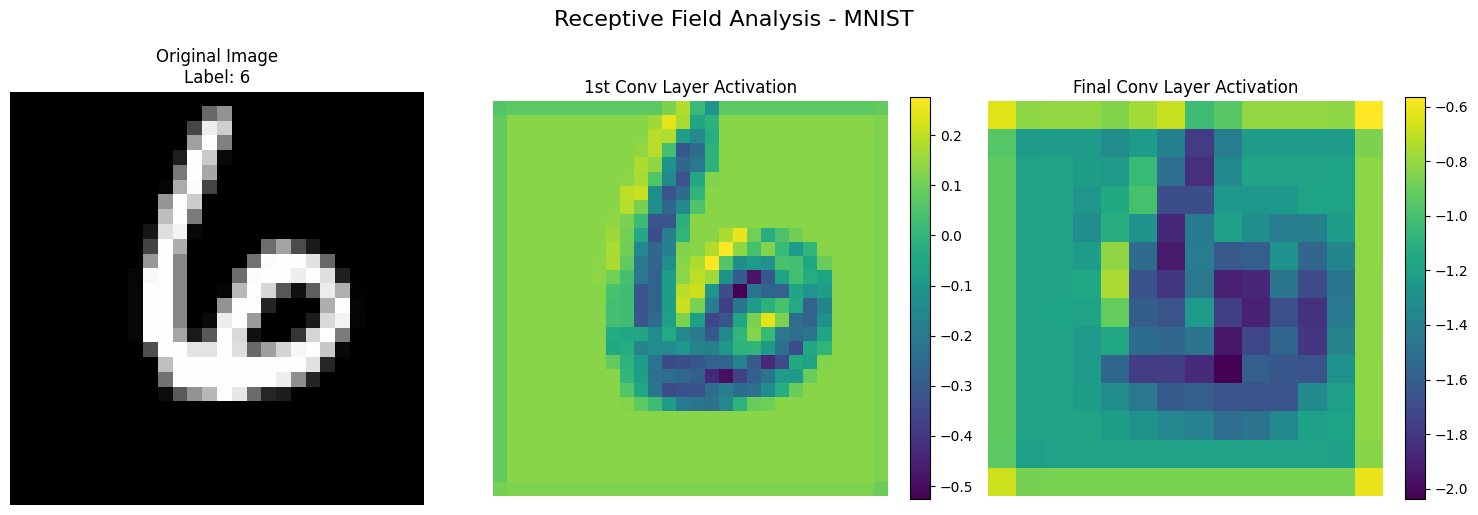

Saved receptive_field_mnist.png


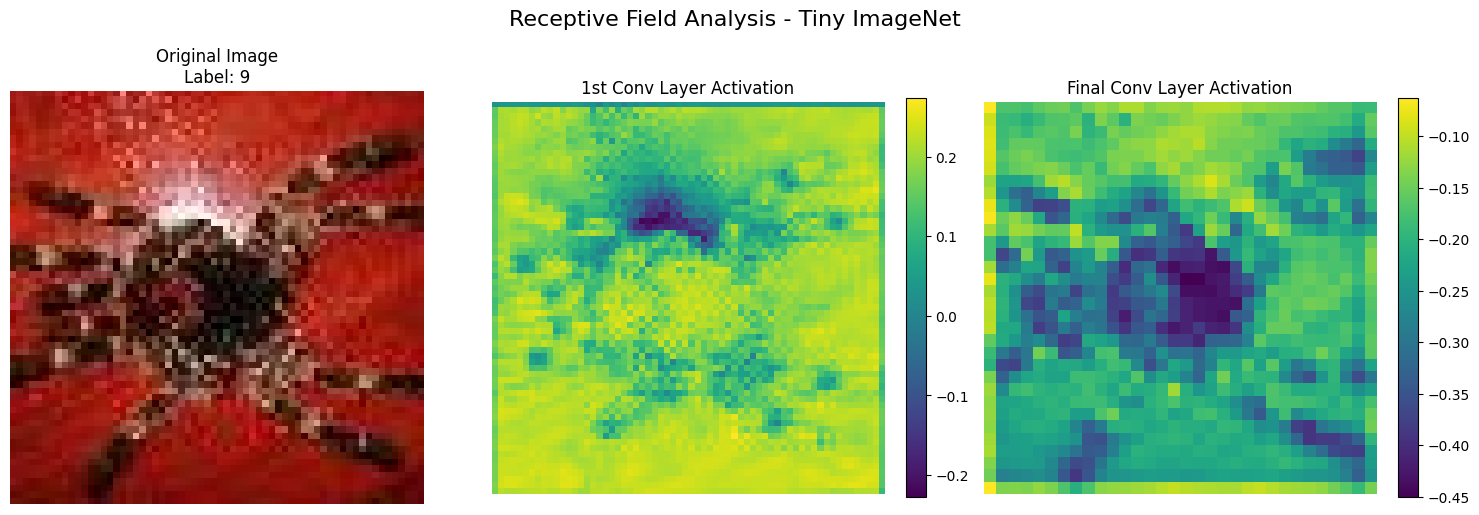

Saved receptive_field_tiny.png


In [ ]:
def get_activation(name, activations):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

def visualize_activations(model, image, label, dataset_name, save_name):
    activations = {}
    
    # Register hooks
    hook1 = model.layer1[0].register_forward_hook(get_activation('conv1', activations))
    hook2 = model.layer2[0].register_forward_hook(get_activation('conv2', activations))
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        _ = model(image)
    
    # Remove hooks
    hook1.remove()
    hook2.remove()
    
    # Get activations
    conv1_act = activations['conv1'][0]  # [channels, H, W]
    conv2_act = activations['conv2'][0]  # [channels, H, W]
    
    # Average across channels for visualization
    conv1_map = conv1_act.mean(dim=0).cpu().numpy()
    conv2_map = conv2_act.mean(dim=0).cpu().numpy()
    
    # Prepare original image
    img = image[0].cpu().numpy()
    if img.shape[0] == 1:  # MNIST
        img = img[0]
        cmap_img = 'gray'
    else:  # Tiny ImageNet
        img = img.transpose(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min())
        cmap_img = None
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img, cmap=cmap_img)
    axes[0].set_title(f'Original Image\nLabel: {label}', fontsize=12)
    axes[0].axis('off')
    
    im1 = axes[1].imshow(conv1_map, cmap='viridis')
    axes[1].set_title('1st Conv Layer Activation', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    im2 = axes[2].imshow(conv2_map, cmap='viridis')
    axes[2].set_title('Final Conv Layer Activation', fontsize=12)
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    fig.suptitle(f'Receptive Field Analysis - {dataset_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, save_name), dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {save_name}")

# MNIST Analysis
sample_mnist, label_mnist = next(iter(loader_mnist))
sample_mnist = sample_mnist[0:1].to(device)
label_mnist = label_mnist[0].item()

visualize_activations(cnn_mnist, sample_mnist, label_mnist, 
                      "MNIST", "receptive_field_mnist.png")

# Tiny ImageNet Analysis
if loader_tiny:
    sample_tiny, label_tiny = next(iter(loader_tiny))
    sample_tiny = sample_tiny[0:1].to(device)
    label_tiny = label_tiny[0].item()
    
    visualize_activations(cnn_tiny, sample_tiny, label_tiny, 
                          "Tiny ImageNet", "receptive_field_tiny.png")
